---
authors:
  - name: Lukas Heumos
  - name: Mohammad Lotfollahi
  - name: Yuge Ji
    roles:
      - writing – review & editing
---


(conditions-perturbation-modeling)=
# Perturbation modeling
```{dropdown} 🧠 Key takeaways

:::{card}
:link: #conditions-perturbation-modeling-key-takeaway-1
Pooled CRISPR screens with single-cell readouts measure the transcriptional effects of many genetic perturbations in one experiment, starting from the assignment of guides to cells.
:::

:::{card}
:link: #conditions-perturbation-modeling-key-takeaway-2
Perturbations fail in many cells, so perturbed cells should be identified, for example with Mixscape, and differential expression should be tested on pseudobulks of replicates.
:::

:::{card}
:link: #conditions-perturbation-modeling-key-takeaway-3
The E-distance and E-test quantify and test the effect of each perturbation, and clustering perturbations by their effects recovers complexes and pathways.
:::

```
``````{dropdown} ⚙️ Environment setup
`````{tab-set}

````{tab-item} Steps
```{include} ../_static/default_text_env_setup.md
```
````

````{tab-item} yml
```{literalinclude} perturbation_modeling.yml
:language: yaml
```
````

`````
``````
````{dropdown} 🗄️ Get data and notebooks
```{include} ../_static/default_text_lamindb_setup.md
```
````
<!-- END DROPDOWNS -->


(conditions-perturbation-modeling-key-takeaway-1)=
## Motivation

Perturbation screens measure how cells respond when a gene or a pathway is disrupted.
Pooled CRISPR screens with single-cell readouts such as Perturb-seq and CROP-seq introduce one guide RNA per cell, sequence the guide together with the transcriptome, and thereby measure the effect of hundreds to thousands of genetic perturbations in a single experiment {cite:p}`pemo:dixit2016,pemo:adamson2016,pemo:datlinger2017`.
Genome-scale screens now cover every expressed gene {cite:p}`pemo:replogle2022`, and similar designs measure the effects of chemical compounds at several doses {cite:p}`pemo:srivatsan2020`.

The analysis of such screens follows a common path: assign guides to cells, identify the cells in which the perturbation worked, quantify and test the effect of each perturbation, find the genes it affects, and group perturbations with similar effects.
We follow this path with pertpy {cite:p}`pemo:heumos2026` on two screens, a multimodal screen of immune checkpoint regulators and a genome-scale screen of essential genes.

In [1]:
import warnings

import lamindb as ln
import numpy as np
import pandas as pd
import pertpy as pt
import scanpy as sc

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="var_names are not unique")
warnings.filterwarnings("ignore", message="As the residual degrees of freedom")

ln.connect("theislab/sc-best-practices")

ln.track("ABrLmpTovdzk")

→ connected lamindb: theislab/sc-best-practices


! It looks like you are running jupyter lab but don't have jupyter-server module installed. Please install it via pip install jupyter-server


→ loaded Transform('ABrLmpTovdzk0000', key='perturbation_modeling.ipynb'), started new Run('sP7tADr5CHcJqFWW') at 2026-09-30 12:49:11 UTC


→ notebook imports: lamindb-core==2.10.0 numpy==2.5.3 pandas==3.0.6 pertpy==1.3.0 scanpy==1.12.4


## Dataset

Papalexi et al. targeted 26 genes that regulate the immune checkpoint PD-L1 in THP-1 cells with 111 guide RNAs and three biological replicates {cite:p}`pemo:papalexi2021`.
Their ECCITE-seq protocol measures the transcriptome, four surface proteins including PD-L1, hashtags for sample multiplexing and the guide RNAs of every cell.

In [2]:
mdata = ln.Artifact.get(
    key="conditions/perturbation_modeling/papalexi_2021.h5mu"
).load()
mdata

MuData object with n_obs × n_vars = 20729 × 18776
  obs:	'MULTI_ID', 'HTO_classification', 'guide_ID', 'gene_target', 'NT', 'perturbation', 'replicate', 'S.Score', 'G2M.Score', 'phase'
  var:	'name'
  4 modalities
    rna:	20729 × 18649
      obs:	'nCount_RNA', 'nFeature_RNA', 'percent.mito'
      var:	'name'
      layers:	None
    adt:	20729 × 4
      obs:	'nCount_ADT', 'nFeature_ADT'
      var:	'name'
      layers:	None
    hto:	20729 × 12
      obs:	'nCount_HTO', 'nFeature_HTO', 'technique'
      var:	'name'
      layers:	None
    gdo:	20729 × 111
      obs:	'nCount_GDO'
      var:	'name'
      layers:	None

## Assigning guides

Every downstream result depends on knowing which guide a cell received.
The guide counts are noisy, since ambient guide RNA is captured in every droplet, so we assign a cell the guide with the most counts only if it has at least five of them {cite:p}`pemo:braunger2024`.

In [3]:
gdo = mdata["gdo"]
gdo.layers["counts"] = gdo.X.copy()
guides = pt.pp.GuideAssignment()
guides.assign_to_max_guide(gdo, assignment_threshold=5, layer="counts")
gdo.obs["assigned_guide"].value_counts().head()

assigned_guide
IFNGR2g1    579
ATF2g1      500
NTg7        445
NTg4        431
IFNGR1g3    416
Name: count, dtype: int64

Each guide is carried by a few hundred cells, and cells whose most abundant guide has fewer than five counts remain unassigned.

In [4]:
(gdo.obs["assigned_guide"].astype(str) == mdata.obs["guide_ID"].astype(str)).mean()

np.float64(1.0)

Our assignment agrees with the one published by the authors for every cell.

(conditions-perturbation-modeling-key-takeaway-2)=
## Identifying perturbed cells

CRISPR edits do not succeed in every cell, so many cells that received a targeting guide still express their target normally, and their inclusion dilutes the measured effects.
Mixscape first removes technical and biological variation that is shared with the control cells of the same replicate by subtracting the mean expression of each cell's nearest control neighbors.
It then classifies every targeted cell as perturbed (KO) or not perturbed (NP) with a mixture model on this perturbation signature {cite:p}`pemo:papalexi2021`.

In [5]:
rna = mdata["rna"].copy()
rna.obs = mdata.obs[["guide_ID", "gene_target", "perturbation", "replicate"]].copy()
rna.layers["counts"] = rna.X.copy()
sc.pp.normalize_total(rna)
sc.pp.log1p(rna)
sc.pp.highly_variable_genes(rna, n_top_genes=2000, subset=True)
sc.pp.pca(rna)
mixscape = pt.tl.Mixscape()
mixscape.perturbation_signature(
    rna, pert_key="perturbation", control="NT", split_by="replicate", n_neighbors=20
)
mixscape.mixscape(rna, pert_key="gene_target", control="NT", layer="X_pert")

In [6]:
rna.obs.groupby("gene_target", observed=True)["mixscape_class_global"].value_counts(
    normalize=True
).unstack().sort_values("KO", ascending=False).head(10)

mixscape_class_global,KO,NP,NT
gene_target,,,
JAK2,0.790039,0.209961,NaN
SMAD4,0.778452,0.221548,NaN
STAT1,0.761261,0.238739,NaN
IFNGR2,0.746908,0.253092,NaN
IFNGR1,0.730798,0.269202,NaN
IRF1,0.593663,0.406337,NaN
STAT2,0.423601,0.576399,NaN
BRD4,0.325513,0.674487,NaN
SPI1,0.291667,0.708333,NaN


Mixscape detects a perturbation in about three quarters of the cells targeting JAK2, SMAD4, STAT1, IFNGR1 and IFNGR2, whereas most cells targeting other genes are classified as not perturbed.
For those genes, either the knockout failed or it does not change the transcriptome of THP-1 cells, which the classification cannot distinguish.

The surface protein measurements provide an independent check.
Knocking out the interferon-γ receptor or its downstream signaling should reduce PD-L1, whose expression THP-1 cells induce in response to interferon-γ.

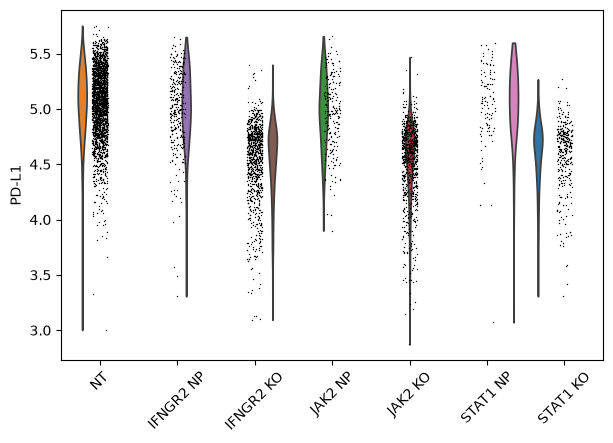

In [7]:
adt = mdata["adt"].copy()
sc.pp.normalize_total(adt)
sc.pp.log1p(adt)
rna.obs["PD-L1"] = adt[rna.obs_names, "PDL1"].X.toarray().ravel()
classes = ["NT", "IFNGR2 NP", "IFNGR2 KO", "JAK2 NP", "JAK2 KO", "STAT1 NP", "STAT1 KO"]
sc.pl.violin(
    rna[rna.obs["mixscape_class"].isin(classes)].copy(),
    "PD-L1",
    groupby="mixscape_class",
    order=classes,
    rotation=45,
)

PD-L1 is lower in the knockout cells of IFNGR2, JAK2 and STAT1 than in the control cells and in the cells classified as not perturbed, which confirms the classification with an independent measurement.

Mixscale extends this approach with a continuous score of perturbation strength per cell, which retains cells with partial effects {cite:p}`pemo:jiang2025`.

## Differential expression per perturbation

To find the genes affected by a perturbation, we compare the perturbed cells with the control cells.
Cells of the same replicate are not independent samples, so we sum the counts of each group per replicate and test the resulting pseudobulks with PyDESeq2, as described in the [differential gene expression chapter](differential_gene_expression.ipynb) {cite:p}`pemo:squair2021`.
We compare the cells in which IFNGR2 was knocked out with the control cells.

In [8]:
counts = mdata["rna"][rna.obs_names].copy()
counts.obs = rna.obs[["mixscape_class", "replicate"]].copy()
counts = counts[counts.obs["mixscape_class"].isin(["NT", "IFNGR2 KO"])].copy()
pseudobulk = pt.tl.PseudobulkSpace().compute(
    counts, target_col="mixscape_class", groups_col="replicate", mode="sum"
)
pds2 = pt.tl.PyDESeq2(adata=pseudobulk, design="~ replicate + mixscape_class")
pds2.fit()
results = pds2.test_contrasts(
    pds2.contrast(column="mixscape_class", baseline="NT", group_to_compare="IFNGR2 KO")
)

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.



Fitting dispersions...


... done in 0.94 seconds.

Fitting dispersion trend curve...


... done in 0.23 seconds.

Fitting MAP dispersions...


... done in 1.02 seconds.

Fitting LFCs...


... done in 1.15 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value, contrast vector: [ 0.  0.  0. -1.]
                baseMean  log2FoldChange     lfcSE      stat    pvalue  \
index                                                                    
AL627309.1      3.567120       -2.751477  1.470535 -1.871072  0.061335   
AP006222.2     32.087337        0.334094  0.378640  0.882354  0.377586   
RP4-669L17.10   2.454185        0.173563  1.332640  0.130240  0.896377   
RP11-206L10.3   6.113561       -0.344735  0.857671 -0.401943  0.687726   
RP11-206L10.2  16.437865        0.835091  0.534201  1.563252  0.117993   
...                  ...             ...       ...       ...       ...   
L3MBTL4         0.000000             NaN       NaN       NaN       NaN   
CTB-31O20.9     0.215351       -0.356789  4.360549 -0.081822  0.934788   
AC092295.4      0.112910        0.441008  4.463447  0.098804  0.921294   
MYO18B          0.307379        2.212641  4.396574  0.503265  0.614778   
TMPRSS3         0.204883        0.01712

... done in 0.80 seconds.



NaNs encountered, dropping rows with NaNs


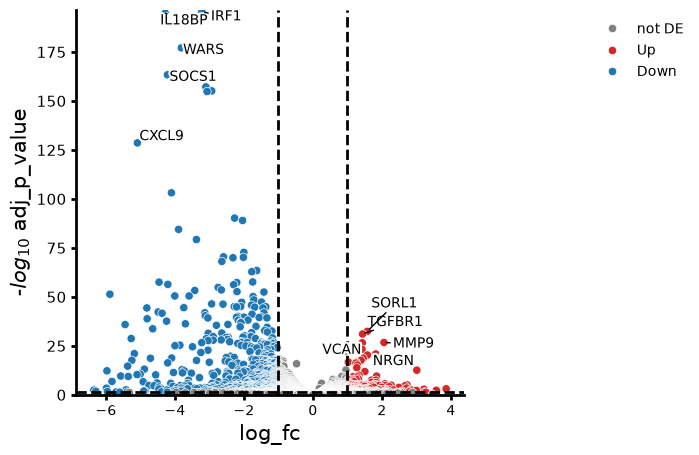

In [9]:
pds2.plot_volcano(results, log2fc_threshold=1)

Knocking out IFNGR2 reduces interferon-γ response genes such as IRF1, SOCS1, CXCL9 and IL18BP, as expected from the loss of interferon-γ signaling.
With three replicates per group, the dispersion estimates of PyDESeq2 rest on few degrees of freedom, so more replicates would make the results more robust.

(conditions-perturbation-modeling-key-takeaway-3)=
## Comparing perturbations at scale

Genome-scale screens raise questions about the perturbations themselves: which of them change the transcriptome at all, and which act alike.
Replogle et al. knocked down every essential gene in K562 cells with CRISPR interference {cite:p}`pemo:replogle2022`.
We use at most 50 cells per perturbation and all control cells.

In [10]:
adata = ln.Artifact.get(
    key="conditions/perturbation_modeling/replogle_2022_k562_essential.h5ad"
).load()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000, subset=True)
sc.pp.pca(adata, n_comps=50)
adata

AnnData object with n_obs × n_vars = 109565 × 2000
    obs: 'batch', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'guide_id', 'percent_mito', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'disease', 'cancer', 'cell_line', 'sex', 'age', 'perturbation', 'organism', 'perturbation_type', 'tissue_type', 'ncounts', 'ngenes', 'nperts', 'percent_ribo'
    var: 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'ensembl_id', 'ncounts', 'ncells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: None (.X)

### Effect size

The energy distance (E-distance) compares the distribution of perturbed cells with that of control cells in a low-dimensional space, relative to the spread within each group {cite:p}`pemo:peidli2024`.
It is zero if both groups are indistinguishable and grows with the strength of the perturbation.

In [11]:
distance = pt.tl.Distance("edistance", obsm_key="X_pca")
edistances = (
    distance.onesided_distances(
        adata, groupby="perturbation", selected_group="control", show_progressbar=False
    )
    .drop("control")
    .sort_values(ascending=False)
)
edistances.head(10)

perturbation
GATA1     7.643471
HSPA9     7.529457
EIF2S1    7.038001
AQR       6.883053
SNRPD2    6.600380
PHB       6.351600
MED30     6.015050
EP400     5.454351
CHMP3     5.395464
INTS2     5.348413
Name: edistance to control, dtype: float64

The strongest effects come from knocking down GATA1, the master regulator of the erythroid program of K562 cells, and core components of protein folding, translation, splicing and the Mediator complex.

The E-test assesses whether a perturbation differs from the controls by comparing its E-distance with those obtained after permuting the labels.
Since each test requires many permutations, we test a selection of the strongest and of random perturbations against a subsample of the controls.

In [12]:
rng = np.random.default_rng(0)
tested = list(edistances.index[:10]) + list(
    rng.choice(edistances.index[10:], 10, replace=False)
)
controls = adata.obs_names[adata.obs["perturbation"] == "control"]
cells = adata.obs_names[adata.obs["perturbation"].isin(tested)].append(
    pd.Index(rng.choice(controls, 1000, replace=False))
)
etest = pt.tl.DistanceTest("edistance", n_perms=1000, obsm_key="X_pca")
etest_results = etest(
    adata[cells].copy(),
    groupby="perturbation",
    contrast="control",
    show_progressbar=False,
)
etest_results.sort_values("distance", ascending=False)

,distance,pvalue,significant,pvalue_adj,significant_adj
GATA1,7.831166,0.001,True,0.020791,True
HSPA9,7.562814,0.001,True,0.020791,True
SNRPD2,7.144025,0.001,True,0.020791,True
EIF2S1,7.085216,0.001,True,0.020791,True
AQR,7.004352,0.001,True,0.020791,True
PHB,6.415536,0.001,True,0.020791,True
MED30,6.190297,0.001,True,0.020791,True
EP400,5.663983,0.001,True,0.020791,True
CHMP3,5.573146,0.001,True,0.020791,True
INTS2,5.502643,0.001,True,0.020791,True


All ten strong perturbations and seven of the ten random ones differ significantly from the controls after correcting for multiple testing.
Many knockdowns of essential genes change the transcriptome only subtly, which the E-test detects even for small E-distances.

### Perturbations with similar effects

Perturbations of genes in the same complex or pathway cause similar transcriptional changes.
We summarize each of the strongest perturbations by the mean of its cells in the PCA space, cluster these profiles, and list the genes in each cluster.

In [13]:
strong = adata[adata.obs["perturbation"].isin(edistances.index[:200])].copy()
profiles = pt.tl.PseudobulkSpace().compute(
    strong, target_col="perturbation", embedding_key="X_pca", mode="mean"
)
sc.pp.neighbors(profiles, use_rep="X", n_neighbors=5)
sc.tl.leiden(profiles, resolution=2, flavor="igraph", n_iterations=2)
pd.set_option("display.max_colwidth", None)
profiles.obs.groupby("leiden", observed=True).apply(
    lambda group: ", ".join(group.index)
).to_frame("perturbations")

,perturbations
leiden,
0,"AARS, AFG3L2, CARS, DARS, DNAJC19, EIF2B2, EIF2B3, EIF2B4, EIF2B5, ETF1, FARSA, FARSB, GSPT1, HARS, NARS, PAM16, PRELID3B, QARS, ROMO1, SARS, SETD1A, TARS, TIMM23B, VARS"
1,"ABCE1, DDX56, NOP2, RPL5, RPL6, RPL7A, RPL8, RPL14, RPL15, RPL17, RPL18, RPL19, RPL21, RPL23, RPL23A, RPL24, RPL26, RPL27, RPL27A, RPL30, RPL31, RPL36, RPL37A, RPL38"
2,"ATF5, HEATR1, NUP62, POLR1B, RRN3, TWISTNB, UTP15, XPO1"
3,"AQR, DHX15, INTS4, INTS9, NAA38, POT1, PRPF3, PRPF31, RBM25, RUVBL1, SMN2, SNRNP70, SNRPA1, SNRPB, SNRPD1, SNRPD2, SNRPD3, SNRPE, SNRPF, SPC24, SPC25, U2AF1"
4,"BCR, DMAP1, EP400, GAB2, MAX, SFPQ"
5,"CASP8AP2, CHAF1A, CHAF1B, NPAT, SLBP"
6,"CDC73, CTR9, PAF1, RTF1, SUPT16H"
7,"CHMP3, COPB1, HSPA5, NPLOC4, PSMA5, PSMC2, PSMC4, PSMD2, PSMD6, PSMD7, PSMD14, UBA1, VPS28"
8,"CNOT1, INTS2, INTS5, INTS7, INTS8"


The clusters recover known complexes and pathways, such as the large and small ribosomal subunits, the spliceosome, the RNA exosome, the proteasome, the Mediator, Integrator and PAF1 complexes, and aminoacyl-tRNA synthetases together with eIF2B, whose loss activates the integrated stress response {cite:p}`pemo:replogle2022`.
Grouping perturbations by their effects therefore assigns functions to poorly characterized genes that cluster with known complexes.

## Predicting unseen perturbations

Many models aim to predict the transcriptional response to perturbations that were never measured, from variational autoencoders such as scGen {cite:p}`pemo:lotfollahi2019` to foundation models trained on millions of cells.
Independent benchmarks found that none of these models consistently outperformed simple baselines such as the mean response of all training perturbations or linear models {cite:p}`pemo:ahlmanneltze2025,pemo:csendes2025,pemo:kernfeld2025,pemo:wei2026`.
Common evaluation metrics also reward models for reproducing the systematic difference between perturbed and control cells rather than perturbation-specific effects {cite:p}`pemo:vinastorne2026`.
Predictions should therefore be compared with such baselines before they are used to prioritize experiments.

## Quiz

In [14]:
%run ../../scripts/quiz.py

with quiz_tabs():
    flip_card(
        "q1",
        "Why should cells that received a targeting guide but show no perturbation be identified?",
        "CRISPR edits fail in a fraction of cells, and including these cells dilutes the measured effects of the perturbation.",
        back_font_size=15,
    )
    flip_card(
        "q2",
        "Why is differential expression per perturbation tested on pseudobulks?",
        "Cells of the same replicate are not independent samples, and testing them as such inflates false discoveries.",
        back_font_size=15,
    )
    flip_card(
        "q3",
        "How should predictions of unseen perturbation responses be evaluated?",
        "Against simple baselines such as the mean response of the training perturbations, which deep learning and foundation models rarely outperform.",
        back_font_size=15,
    )

## Contributors

We gratefully acknowledge the contributions of:

### Authors

* Lukas Heumos
* Mohammad Lotfollahi

### Reviewers

* Yuge Ji